## Imports and file paths

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

DATA_DIR = Path('../data')
sentiment_path = DATA_DIR / 'fear_greed_index.csv'
trades_path = DATA_DIR / 'historical_data.csv'

## Load and inspect shapes/columns

In [3]:
sentiment_df = pd.read_csv(sentiment_path)
trades_df = pd.read_csv(trades_path)

print("SENTIMENT DATA")
print("Shape:", sentiment_df.shape)
print("Columns:", list(sentiment_df.columns))
print(sentiment_df.head())
print()
print("TRADES DATA")
print("Shape:", trades_df.shape)
print("Columns:", list(trades_df.columns))
print(trades_df.head())

SENTIMENT DATA
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

TRADES DATA
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800        16.00

## Data types and missing values

In [4]:
print("SENTIMENT DTYPES & NULLS")
print(sentiment_df.info())
print(sentiment_df.isnull().sum())
print()
print("TRADES DTYPES & NULLS")
print(trades_df.info())
print(trades_df.isnull().sum())

SENTIMENT DTYPES & NULLS
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None
timestamp         0
value             0
classification    0
date              0
dtype: int64

TRADES DTYPES & NULLS
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side         

## Key column exploration

In [6]:
print("Sentiment classification unique values:")
print(sentiment_df['classification'].value_counts())
print()
print("Sentiment date range:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())
print()
print("Trades timestamp (IST) sample range:")
print(trades_df['Timestamp IST'].min(), "to", trades_df['Timestamp IST'].max())
print()
print("Unique coins traded:", trades_df['Coin'].nunique())
print("Unique accounts:", trades_df['Account'].nunique())
print()
print("Side value counts:")
print(trades_df['Side'].value_counts())
print()
print("Direction value counts:")
print(trades_df['Direction'].value_counts())

Sentiment classification unique values:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Sentiment date range: 2018-02-01 to 2025-05-02

Trades timestamp (IST) sample range:
01-01-2024 01:23 to 31-12-2024 23:33

Unique coins traded: 246
Unique accounts: 32

Side value counts:
Side
SELL    108528
BUY     102696
Name: count, dtype: int64

Direction value counts:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [7]:
print("Duplicate rows in trades:", trades_df.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment_df.duplicated().sum())
print()
print("Closed PnL summary stats:")
print(trades_df['Closed PnL'].describe())
print()
print("Rows with Closed PnL == 0:", (trades_df['Closed PnL'] == 0).sum(), 
      f"({(trades_df['Closed PnL'] == 0).mean()*100:.1f}%)")

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0

Closed PnL summary stats:
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

Rows with Closed PnL == 0: 106816 (50.6%)


In [8]:
pd.set_option('display.max_rows', None)
print(trades_df['Direction'].value_counts())
pd.reset_option('display.max_rows')

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [9]:
# Parse trades timestamp (IST format: DD-MM-YYYY HH:MM)
trades_df['datetime'] = pd.to_datetime(trades_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades_df['trade_date'] = trades_df['datetime'].dt.date

# Parse sentiment date (already looks like YYYY-MM-DD)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

print("Trades date range:", trades_df['trade_date'].min(), "to", trades_df['trade_date'].max())
print("Trades unique dates:", trades_df['trade_date'].nunique())
print("Sentiment unique dates:", sentiment_df['date'].nunique())

# Check for gaps: does every trade date have a matching sentiment entry?
trade_dates = set(trades_df['trade_date'])
sentiment_dates = set(sentiment_df['date'])
missing_dates = trade_dates - sentiment_dates
print(f"\nTrade dates with NO matching sentiment record: {len(missing_dates)}")
if missing_dates:
    print(sorted(missing_dates)[:10], "...")

Trades date range: 2023-05-01 to 2025-05-01
Trades unique dates: 480
Sentiment unique dates: 2644

Trade dates with NO matching sentiment record: 1
[datetime.date(2024, 10, 26)] ...


In [10]:
merged_df = trades_df.merge(
    sentiment_df[['date', 'classification', 'value']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

print("Merged shape:", merged_df.shape)
print("Rows with no sentiment match:", merged_df['classification'].isnull().sum())
merged_df[['Account', 'Coin', 'trade_date', 'classification', 'value', 'Closed PnL']].head(10)

Merged shape: (211224, 21)
Rows with no sentiment match: 6


,Account,Coin,trade_date,classification,value,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0


## Feature Engineering

### Drop unmatched rows and rename for clarity

In [11]:
df = merged_df.dropna(subset=['classification']).copy()
df = df.rename(columns={'classification': 'sentiment', 'value': 'sentiment_score'})
print("Final analysis dataset shape:", df.shape)

Final analysis dataset shape: (211218, 21)


### Flag closing vs opening trades

In [12]:
closing_directions = ['Close Long', 'Close Short', 'Short > Long', 'Long > Short', 
                       'Liquidated Isolated Short', 'Auto-Deleveraging', 'Settlement']
df['is_closing_trade'] = df['Direction'].isin(closing_directions)

print(df.groupby('is_closing_trade')['Closed PnL'].agg(['count', 'mean', lambda x: (x==0).mean()]))

                   count       mean  <lambda_0>
is_closing_trade                               
False             126396  22.997155    0.844568
True               84822  86.625386    0.000778


### Win/loss flag

In [14]:
df['is_win'] = df['Closed PnL'] > 0
df['is_loss'] = df['Closed PnL'] < 0

### Simplify sentiment into a broader bucket

In [15]:
sentiment_map = {
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
}
df['sentiment_broad'] = df['sentiment'].map(sentiment_map)
print(df['sentiment_broad'].value_counts())

sentiment_broad
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64


### Core aggregation

In [16]:
closes = df[df['is_closing_trade']]

summary = closes.groupby('sentiment').agg(
    trade_count=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    win_rate=('is_win', 'mean'),
    avg_size_usd=('Size USD', 'mean')
).sort_values('avg_pnl', ascending=False)

print(summary)

               trade_count     total_pnl     avg_pnl  median_pnl  win_rate  avg_size_usd
sentiment                                                                               
Fear                 26513  3.367722e+06  127.021555     7.11066  0.885792   8871.173206
Extreme Fear          9369  8.798029e+05   93.905741     8.04972  0.799765   5915.804090
Greed                19369  1.383789e+06   71.443490     3.98160  0.760855   6637.106280
Neutral              15870  1.082913e+06   68.236499     4.40185  0.829931   6119.520896
Extreme Greed        13701  6.335110e+05   46.238301     7.09764  0.873805   3491.669771


In [17]:
Path('../data/processed').mkdir(exist_ok=True)
df.to_csv('../data/processed/merged_trades_sentiment.csv', index=False)
print("Saved processed dataset")

Saved processed dataset


## Statistical Validation & Visualizations

### Statistical test

In [18]:
from scipy import stats

groups = [closes[closes['sentiment']==s]['Closed PnL'].values 
          for s in closes['sentiment'].unique()]

# Kruskal-Wallis: non-parametric, appropriate since PnL is heavily skewed (not normal)
h_stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {h_stat:.2f}, p-value: {p_value:.6f}")

Kruskal-Wallis H-statistic: 735.62, p-value: 0.000000


### Win rate chart

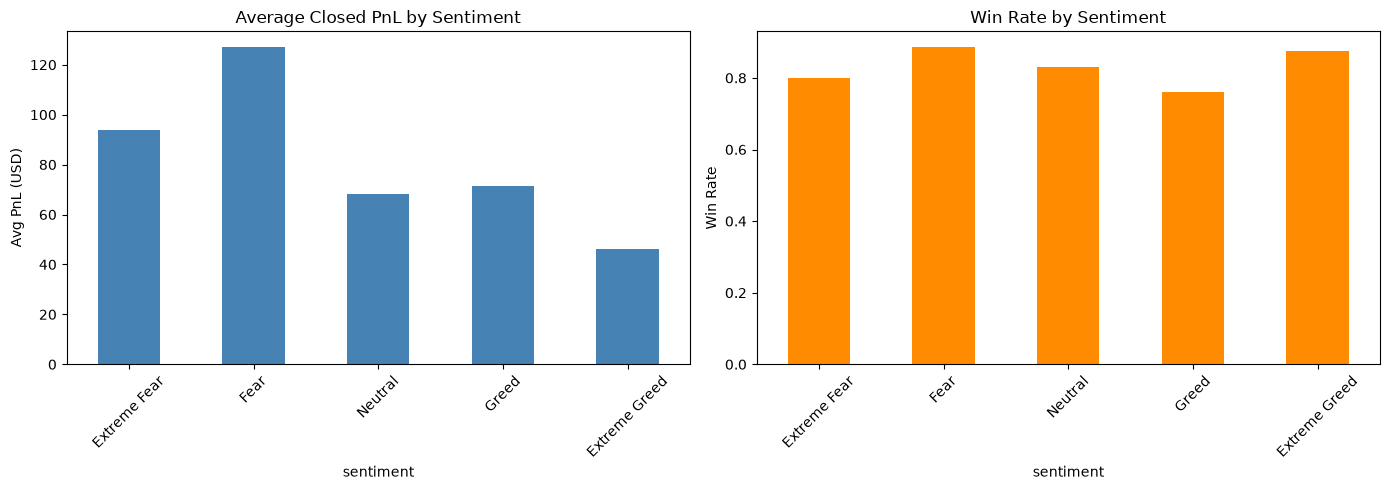

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
summary_ordered = summary.reindex(order)

summary_ordered['avg_pnl'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Closed PnL by Sentiment')
axes[0].set_ylabel('Avg PnL (USD)')
axes[0].tick_params(axis='x', rotation=45)

summary_ordered['win_rate'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/pnl_winrate_by_sentiment.png', dpi=150)
plt.show()

### PnL distribution

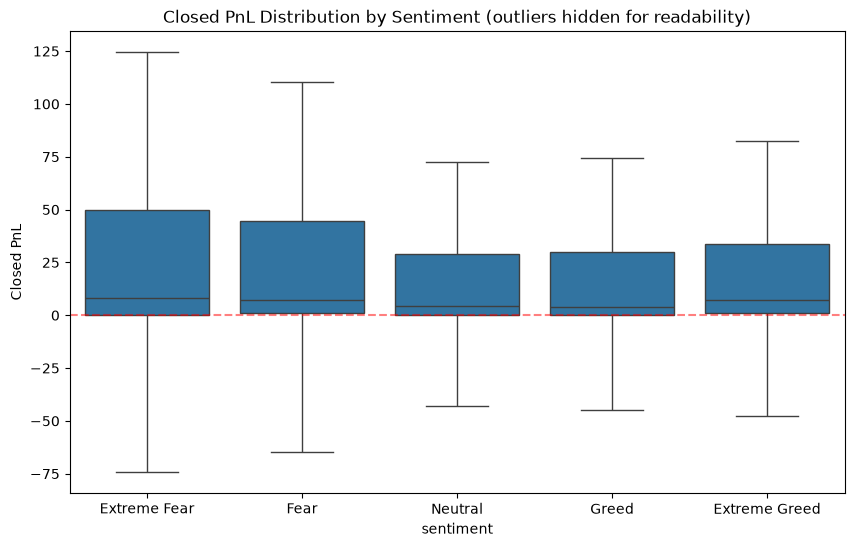

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=closes, x='sentiment', y='Closed PnL', order=order, showfliers=False)
plt.title('Closed PnL Distribution by Sentiment (outliers hidden for readability)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.savefig('../outputs/figures/pnl_distribution_by_sentiment.png', dpi=150)
plt.show()

### Leverage vs sentiment

In [21]:
print([c for c in df.columns if 'lever' in c.lower()])

[]
